In [1]:
import numpy as np
from skimage.color import rgb2gray
from skimage.io import imread, imsave
from olimp.precompensation.nn.dataset import psf_gauss
from olimp.processing import fft_conv
from matplotlib import pyplot as plt
from torch import Tensor
import os
from typing import Dict, Tuple

# Генерация датасета из 36 изображений

In [ ]:
# task initialization

MAX_UINT8_INTENSITY = 255

ORIG_DIRPATH = r"data\orig_images\\"
DEST_DIRPATH = r"data\processed\\"

IMAGE_SIZE = 512
PSF_TUPLE = (
    psf_gauss.PsfGaussDataset(
        height=IMAGE_SIZE, width=IMAGE_SIZE,
        center_x=0, center_y=0,
        theta=0,
        sigma_x=10, sigma_y=10,
        size=1
    ),
    psf_gauss.PsfGaussDataset(
        height=IMAGE_SIZE, width=IMAGE_SIZE,
        center_x=0, center_y=0,
        theta=0,
        sigma_x=5, sigma_y=5,
        size=1
    ),
    psf_gauss.PsfGaussDataset(
        height=IMAGE_SIZE, width=IMAGE_SIZE,
        center_x=0, center_y=0,
        theta=0,
        sigma_x=10, sigma_y=5,
        size=1
    )
)

STANDART_DEVIATIONS = (0.01, 0.05, 0.1)  # for noise

np.random.seed(42)

In [7]:
def preprocess_image(
    image: np.ndarray,
) -> np.ndarray:
    """
    Transforms colored image to gray and changes dtype from uint8 [0, 255] to float32 [0, 1].
    """
    image_float = image.astype(np.float32) / MAX_UINT8_INTENSITY
    gray = rgb2gray(image_float)
    return gray


def load_images(
    orig_dirpath: str
) -> Dict[str, np.ndarray]:
    """
    Loads and preprocesses original images.
    """
    images = dict()

    for filename in os.listdir(orig_dirpath):
        images[filename] = preprocess_image(imread(orig_dirpath + os.path.basename(filename)))
    
    return images


def add_gaussian_noise(
    image: np.ndarray,
    std: float
) -> np.ndarray:
    """
    Adds Gaussian noise N(0, std^2) to image.
    """
    blurred_image = image + np.random.normal(0, std, image.shape)
    blurred_image.clip(0, 1)
    return blurred_image


def process_triplet(
    image: np.ndarray,
    psf: Tensor,
    std: float
) -> Dict[str, np.ndarray]:
    """
    Processes single image and returns Dict of original, convoluted & blurred images.
    """
    convoluted_image = fft_conv(Tensor(image), psf).numpy()

    return {
        "orig.png": image,
        "conv.png": convoluted_image,
        "blur.png": add_gaussian_noise(convoluted_image, std)
    }


def save_triplet(
    triplet: Dict[str, np.ndarray],
    dest: str
) -> None:
    """
    Saves single image triplet on dest.
    """
    for name in triplet.keys():
        imsave(dest + name, np.uint8(triplet[name] * MAX_UINT8_INTENSITY))


def save_processed_images(
    images: Dict[str, np.ndarray],
    psf_tuple: Tuple[psf_gauss.PsfGaussDataset],
    std_tuple: Tuple[float, float, float],
    dest_dirpath: str
) -> None:
    """
    Processes & saves images.
    """
    for name in images.keys():
        for i, psf in enumerate(psf_tuple):
            for std in std_tuple:
                dest = dest_dirpath + f"img_{name}.psf_{i}.std_{std:.2f}\\"
                os.mkdir(dest)
                save_triplet(process_triplet(images[name], psf[0], std), dest)

def generate_dataset(
    orig_dirpath: str,
    dest_dirpath: str,
    psf_tuple: Tuple[psf_gauss.PsfGaussDataset],
    std_tuple: Tuple[float, float, float],
) -> None:
    """
    Generates dataset.
    """
    images = load_images(orig_dirpath)
    save_processed_images(images, psf_tuple, std_tuple, dest_dirpath)



In [ ]:
generate_dataset(
    ORIG_DIRPATH,
    DEST_DIRPATH,
    PSF_TUPLE,
    STANDART_DEVIATIONS
)

dataset size: 36


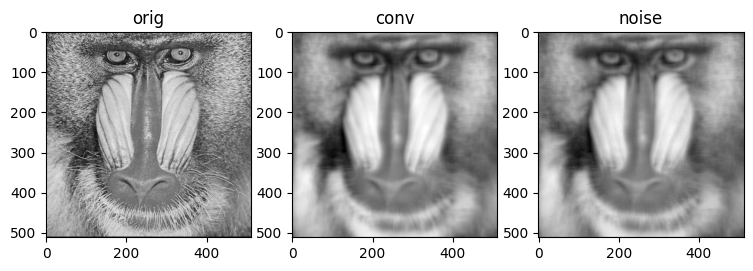

In [5]:
print(f"dataset size: {len(os.listdir(DEST_DIRPATH))}")

fig, axes = plt.subplots(1, 3, figsize=(9, 27))

axes[0].imshow(imread(r"data\processed\img_4.2.03.tiff.psf_0.std_0.01\orig.png"), cmap='gray')
axes[1].imshow(imread(r"data\processed\img_4.2.03.tiff.psf_0.std_0.01\conv.png"), cmap='gray')
axes[2].imshow(imread(r"data\processed\img_4.2.03.tiff.psf_0.std_0.01\blur.png"), cmap='gray')

axes[0].set_title("orig")
axes[1].set_title("conv")
axes[2].set_title("noise")

plt.show()